# 🥫 EDA — Open Food Facts: NOVA Group Classification

**Tujuan:** Eksplorasi awal dataset Open Food Facts untuk memahami struktur data, distribusi target variable (`nova_group`), missing values, dan profil nutrisi per kelompok pemrosesan makanan.

**Dataset:** [Open Food Facts @ HuggingFace](https://huggingface.co/datasets/openfoodfacts/product-database)  
**Tool:** DuckDB (query langsung ke file `.parquet` lokal)  
**Konteks:** SDG 12 — Responsible Consumption and Production

---

## 0. Setup

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

con = duckdb.connect(database=':memory:')
FILE = 'food.parquet'

print('DuckDB version:', duckdb.__version__)
print('Setup selesai.')

DuckDB version: 1.5.3
Setup selesai.


---
## 1. Schema — Struktur Dataset

Cek jumlah kolom, nama, dan tipe data.

In [3]:
df_schema = con.execute(f"DESCRIBE SELECT * FROM '{FILE}'").df()
print(f"Total kolom: {len(df_schema)}")
print(df_schema[['column_name', 'column_type']].to_string())

Total kolom: 111
                                column_name                                                                                                                                                                                                                                              column_type
0                               additives_n                                                                                                                                                                                                                                                  INTEGER
1                            additives_tags                                                                                                                                                                                                                                                VARCHAR[]
2                            allergens_tags                                                             

---
## 2. Ukuran Dataset

In [4]:
total = con.execute(f"SELECT COUNT(*) as total FROM '{FILE}'").df()
print("Total baris (produk):")
print(total)

Total baris (produk):
     total
0  4487169


---
## 3. Missing Value Analysis — Kolom Kunci

Mengecek kelengkapan data pada kolom-kolom yang akan digunakan sebagai fitur dan target ML.

> **Catatan:** Query ini scan full dataset (~4.4 juta baris). Estimasi waktu: 1–2 menit.

In [5]:
query = f"""
SELECT 
    COUNT(*)                                          AS total_produk,
    COUNT(nova_group)                                 AS ada_nova,
    COUNT(nutriscore_grade)                           AS ada_nutriscore,
    COUNT(nutriments)                                 AS ada_nutriments,
    COUNT(additives_n)                                AS ada_additives,
    COUNT(ingredients_text)                           AS ada_ingredients_text,
    ROUND(COUNT(nova_group)        * 100.0 / COUNT(*), 1) AS pct_nova,
    ROUND(COUNT(nutriscore_grade)  * 100.0 / COUNT(*), 1) AS pct_nutriscore,
    ROUND(COUNT(nutriments)        * 100.0 / COUNT(*), 1) AS pct_nutriments,
    ROUND(COUNT(additives_n)       * 100.0 / COUNT(*), 1) AS pct_additives,
    ROUND(COUNT(ingredients_text)  * 100.0 / COUNT(*), 1) AS pct_ingredients_text
FROM '{FILE}'
"""

df_missing = con.execute(query).df()
print("=== MISSING VALUE ANALYSIS (full dataset) ===")
print(df_missing.T.rename(columns={0: 'nilai'}))

=== MISSING VALUE ANALYSIS (full dataset) ===
                          nilai
total_produk          4487169.0
ada_nova              1119410.0
ada_nutriscore        4442848.0
ada_nutriments        3481009.0
ada_additives         1271840.0
ada_ingredients_text  4487169.0
pct_nova                   24.9
pct_nutriscore             99.0
pct_nutriments             77.6
pct_additives              28.3
pct_ingredients_text      100.0


**Insight:**
- `nova_group` hanya terisi ~24.9% → missing value masif, ini tantangan utama
- `nutriscore_grade` sangat lengkap (~99%) → reliable sebagai fitur tambahan
- `nutriments` terisi ~77.6% → perlu investigasi lebih lanjut

---
## 4. Distribusi Target Variable: `nova_group`

Mengecek class imbalance — apakah distribusi NOVA group seimbang?

=== DISTRIBUSI NOVA GROUP ===
   nova_group  jumlah  persen
0           1  133351    11.9
1           2   63691     5.7
2           3  207395    18.5
3           4  714973    63.9


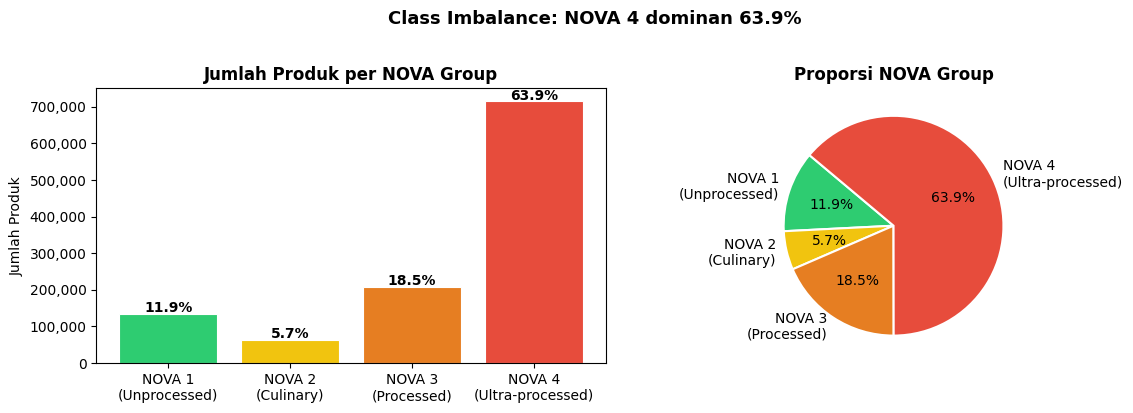


⚠️  Class imbalance terdeteksi → perlu SMOTE atau class_weight saat modeling


In [6]:
query = f"""
SELECT 
    nova_group,
    COUNT(*)                                              AS jumlah,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1)    AS persen
FROM '{FILE}'
WHERE nova_group IS NOT NULL
GROUP BY nova_group
ORDER BY nova_group
"""

df_nova = con.execute(query).df()
print("=== DISTRIBUSI NOVA GROUP ===")
print(df_nova)

# Visualisasi
labels = [
    'NOVA 1\n(Unprocessed)',
    'NOVA 2\n(Culinary)',
    'NOVA 3\n(Processed)',
    'NOVA 4\n(Ultra-processed)'
]
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, df_nova['jumlah'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Jumlah Produk per NOVA Group', fontweight='bold')
axes[0].set_ylabel('Jumlah Produk')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (v, p) in enumerate(zip(df_nova['jumlah'], df_nova['persen'])):
    axes[0].text(i, v + 5000, f'{p}%', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(df_nova['jumlah'], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi NOVA Group', fontweight='bold')

plt.suptitle('Class Imbalance: NOVA 4 dominan 63.9%', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nova_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n⚠️  Class imbalance terdeteksi → perlu SMOTE atau class_weight saat modeling')

---
## 5. Distribusi Geografis — Bias Negara

Dataset Open Food Facts bersifat crowdsourced → berpotensi bias geografis.
Kolom `countries_tags` digunakan untuk investigasi.

In [7]:
query = f"""
WITH sample AS (
    SELECT countries_tags
    FROM '{FILE}'
    LIMIT 100000
)
SELECT countries_tags, COUNT(*) AS jumlah_produk
FROM sample
GROUP BY countries_tags
ORDER BY jumlah_produk DESC
LIMIT 10
"""

df_geo = con.execute(query).df()
print("=== TOP 10 NEGARA (sample 100k baris) ===")
print(df_geo)
print("\n⚠️  US & France mendominasi → geographic bias, perlu dipertimbangkan saat evaluasi model")

=== TOP 10 NEGARA (sample 100k baris) ===
                            countries_tags  jumlah_produk
0                       [en:united-states]          88702
1                              [en:france]           3300
2             [en:united-states, en:world]           2238
3            [en:france, en:united-states]            955
4                              [en:canada]            887
5           [en:france, en:united-kingdom]            799
6                      [en:united-kingdom]            508
7                   [en:canada, en:france]            362
8           [en:germany, en:united-states]            182
9  [en:france, en:united-states, en:world]            112

⚠️  US & France mendominasi → geographic bias, perlu dipertimbangkan saat evaluasi model


---
## 6. Profil Nutrisi per NOVA Group

Kolom `nutriments` bertipe `STRUCT[]` (array of struct). Perlu di-UNNEST terlebih dahulu.
Filter `BETWEEN 0 AND 1000` digunakan untuk membuang outlier data entry error.

=== RATA-RATA NUTRISI PER NOVA GROUP (per 100g) ===
   nova_group  avg_gula_g  avg_lemak_g  avg_kalori_kcal  avg_protein_g  avg_garam_g
0           1        9.49        15.91           220.67          10.74         0.19
1           2       33.69        51.96           564.19           2.23         1.52
2           3       13.88        39.15           244.43          16.29         1.84
3           4       32.36        18.87           284.43           9.17         1.33


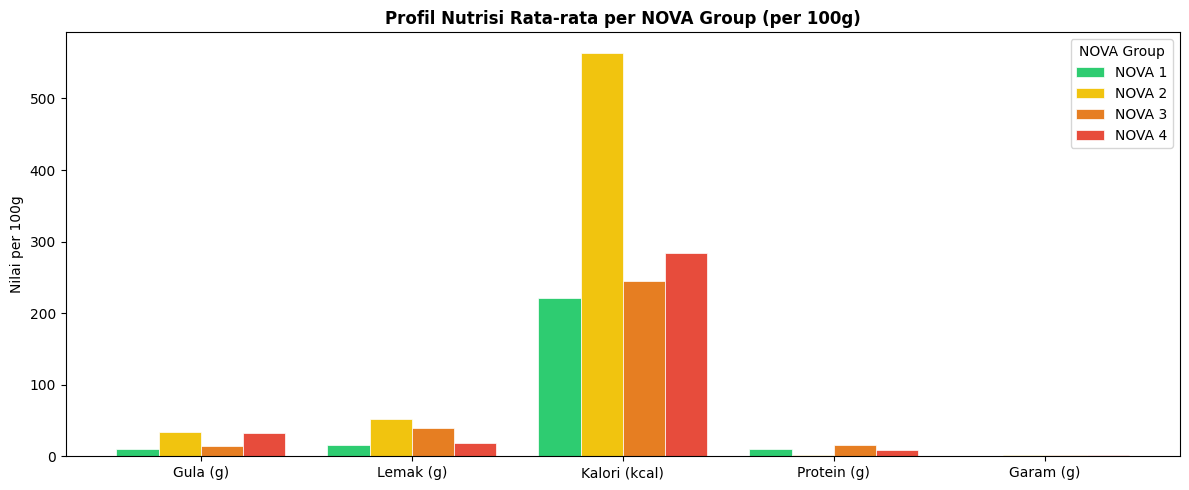

In [8]:
query = f"""
WITH sample AS (
    SELECT nova_group, nutriments
    FROM '{FILE}'
    WHERE nova_group IS NOT NULL
      AND nutriments IS NOT NULL
    LIMIT 100000
),
unnested AS (
    SELECT nova_group, n.name, n."100g"
    FROM sample, UNNEST(nutriments) AS t(n)
    WHERE n."100g" IS NOT NULL
      AND n."100g" BETWEEN 0 AND 1000
)
SELECT 
    nova_group,
    ROUND(AVG(CASE WHEN name = 'sugars'       THEN "100g" END), 2) AS avg_gula_g,
    ROUND(AVG(CASE WHEN name = 'fat'          THEN "100g" END), 2) AS avg_lemak_g,
    ROUND(AVG(CASE WHEN name = 'energy-kcal'  THEN "100g" END), 2) AS avg_kalori_kcal,
    ROUND(AVG(CASE WHEN name = 'proteins'     THEN "100g" END), 2) AS avg_protein_g,
    ROUND(AVG(CASE WHEN name = 'salt'         THEN "100g" END), 2) AS avg_garam_g
FROM unnested
GROUP BY nova_group
ORDER BY nova_group
"""

df_nutrisi = con.execute(query).df()
print("=== RATA-RATA NUTRISI PER NOVA GROUP (per 100g) ===")
print(df_nutrisi)

# Visualisasi
nutrisi_cols = ['avg_gula_g', 'avg_lemak_g', 'avg_kalori_kcal', 'avg_protein_g', 'avg_garam_g']
nutrisi_labels = ['Gula (g)', 'Lemak (g)', 'Kalori (kcal)', 'Protein (g)', 'Garam (g)']
nova_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

x = range(len(nutrisi_cols))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(df_nutrisi.iterrows()):
    offset = (i - 1.5) * width
    bars = ax.bar([xi + offset for xi in x], row[nutrisi_cols].values,
                  width=width, label=f'NOVA {int(row["nova_group"])}',
                  color=nova_colors[i], edgecolor='white', linewidth=0.5)

ax.set_xticks(list(x))
ax.set_xticklabels(nutrisi_labels)
ax.set_title('Profil Nutrisi Rata-rata per NOVA Group (per 100g)', fontweight='bold')
ax.set_ylabel('Nilai per 100g')
ax.legend(title='NOVA Group')
plt.tight_layout()
plt.savefig('nova_nutrisi.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
| NOVA | Karakteristik Dominan |
|------|----------------------|
| 1 (Unprocessed) | Gula & garam paling rendah — makanan alami |
| 2 (Culinary Ingredients) | Lemak & kalori tertinggi — minyak, mentega |
| 3 (Processed) | Protein tertinggi — produk daging/ikan olahan |
| 4 (Ultra-processed) | Gula tinggi, garam tinggi — konsisten dengan literatur |

> Pola ini mengkonfirmasi bahwa fitur `nutriments` memiliki daya prediktif terhadap `nova_group`.

---
## 7. Sample Data Lengkap

Preview 10 produk dengan kolom kunci terisi lengkap.

In [9]:
query = f"""
SELECT 
    code,
    product_name[1]['text']        AS product_name,
    nova_group,
    nutriscore_grade,
    additives_n,
    ingredients_n,
    environmental_score_grade,
    ROUND(completeness, 2)         AS completeness
FROM '{FILE}'
WHERE nova_group IS NOT NULL
  AND nutriscore_grade IS NOT NULL
  AND product_name IS NOT NULL
LIMIT 10
"""

df_sample = con.execute(query).df()
print("=== SAMPLE 10 PRODUK ===")
print(df_sample.to_string(index=False))

=== SAMPLE 10 PRODUK ===
         code                                      product_name  nova_group nutriscore_grade  additives_n  ingredients_n environmental_score_grade  completeness
0000105000011                              Chamomile Herbal Tea           1          unknown            0              1                   unknown          0.60
0000105000042                    Lagg's, herbal tea, peppermint           1          unknown            0              1                       NaN          0.50
0000105000196                              Apple & Cinnamon Tea           4          unknown            0              3                   unknown          0.60
0000105000219                                         Green Tea           1          unknown            0              1                   unknown          0.60
0000105000417                       Lagg's, dieter's herbal tea           1                b            0              6                       NaN          0.50
000011104

---
## 8. Ringkasan Temuan EDA

| Aspek | Temuan | Implikasi |
|-------|--------|-----------|
| **Ukuran data** | 4.487.169 produk, 111 kolom | Dataset besar, query via DuckDB efisien |
| **Target variable** | `nova_group` hanya 24.9% terisi | Perlu strategi: drop null atau semi-supervised |
| **Class imbalance** | NOVA 4 = 63.9%, NOVA 2 = 5.7% | Wajib pakai SMOTE / `class_weight='balanced'` |
| **Fitur nutrisi** | `nutriments` = array of struct | Perlu UNNEST + pivot sebelum masuk model |
| **Geographic bias** | US & France dominan | Filter atau stratified sampling per negara |
| **Validasi fitur** | Pola nutrisi konsisten per NOVA | Fitur `nutriments` terbukti informatif |

### Next Step (Silver Layer)
1. Filter produk dengan `nova_group IS NOT NULL`
2. UNNEST `nutriments` → pivot jadi kolom flat
3. Handle missing values per fitur
4. Encode `nutriscore_grade` (A→1, B→2, ..., E→5)
5. Feature engineering dari `additives_tags` dan `ingredients_analysis_tags`